<a href="https://colab.research.google.com/github/yongsa-nut/SF251_68_2/blob/main/SF251_HW5_Linear_Logistic_Regression_(TH).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW 5 - Linear Regression & Logistic Regression

## Due: Thursday 10th, April 2026. 23:59

## Point: 10

**Note**: ถ้ามีปัญหาอ่านโจทย์ไม่เข้าใจ ถามได้นะครับ

## Description:

การบ้านนี้จะแนะนำขั้นตอนพื้นฐานของการทำ machine learning

การบ้านประกอบด้วย 3 ส่วน:
1. **Linear Regression** กับชุดข้อมูล Diabetes จาก `sklearn` (2 points)
2. **Linear Regression** กับชุดข้อมูล Housing จาก Kaggle (3 points)
3. **Logistic Regression** กับชุดข้อมูล Spam/Ham Classification (5 points)

# 1. The Diabetes dataset (2 points)

ในโจทย์ปัญหานี้ เราจะสำรวจชุดข้อมูล diabetes และพยายามทำนายการดำเนินของโรค

**ขั้นตอน**:
1. Import libraries ที่จำเป็น
2. โหลดและแบ่งข้อมูล train/test
3. สำรวจข้อมูล
4. การเลือก Feature และ Feature Engineering
5. การเลือกโมเดลโดยใช้ Cross Validation
6. การฝึกโมเดลที่ดีที่สุดบนชุดข้อมูลเต็ม
7. ตรวจสอบผลลัพธ์

<br>

---

## 1.1 Import necessary libraries

ลองดูสิ่งที่เรานำเข้าทั้งหมด บางอย่างคุณอาจจะยังไม่รู้จัก และการบ้านจะอธิบายให้คุณทราบในภายหลังว่าสิ่งเหล่านั้นถูกใช้อย่างไร

In [ ]:
import pandas as pd
import numpy as np
from plotnine import *

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

## 1.2 Load and split the Diabetes dataset

- โหลดชุดข้อมูลเบาหวานโดยใช้ฟังก์ชัน `load_diabetes()` ของ sklearn
  - คุณสามารถอ่านเพิ่มเติมเกี่ยวกับชุดข้อมูลและตัวแปรได้ที่นี่ (https://scikit-learn.org/1.5/datasets/toy_dataset.html#diabetes-dataset).

In [ ]:
# Load the Diabetes dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
X = pd.DataFrame(X, columns=diabetes.feature_names) # The dataset is is numpy array format

### 1.2.1 Split Training/Testing (0.25 points)

- หากคุณไม่ได้รับ testing set คุณควร **แบ่ง training และ testing ตั้งแต่ตอนเริ่มต้น**
- เหตุผลสำคัญคือ testing set ควรจะบริสุทธิ์และคุณไม่ควรดูมันจนกว่าจะถึงตอนสุดท้าย

คำอธิบายงาน:
- ใช้ `train_test_split` เพื่อแบ่งชุดข้อมูลแต่ละ feature ออกเป็นชุด training และ testing ([เอกสารอ้างอิง](https://scikit-learn.org/1.5/modules/generated/sklearn.model_selection.train_test_split.html))
   - กำหนด `test_size=0.2` เพื่อใช้ข้อมูล 80% สำหรับการ training และ 20% สำหรับการ testing
   - กำหนด `random_state=777` เพื่อให้ผลลัพธ์สามารถทำซ้ำได้
- สุดท้าย print shapes ของชุดข้อมูล training และ testing ที่ได้

In [ ]:
X_train, X_test, y_train, y_test =  train_test_split(...,
                                                     ...,
                                                     test_size=...,
                                                     random_state=...)

print(X_train.shape)
print(X_test.shape)

## 1.3 Data Exploration

### 1.3.0 Exploring the data

- สร้าง pandas DataFrame จากชุดข้อมูลเพื่อให้จัดการได้ง่ายขึ้น
- แสดงข้อมูลพื้นฐานเกี่ยวกับชุดข้อมูลโดยใช้ `df.info()` และ `df.describe()`

In [ ]:
# Create a DataFrame for easier exploration
df = pd.DataFrame(X_train, columns=diabetes.feature_names)
df['target'] = y_train

df.head()

# Display basic information about the dataset
print(df.info())
print("\nDescriptive statistics:")
print(df.describe())

### 1.3.1 Visualizing all the features (0.5 point)

- สร้าง histogram สำหรับทุก feature เพื่อแสดงการกระจายตัวของข้อมูลโดยใช้ plotnine
  - ขั้นแรก สร้าง `DataFrame` ใหม่สำหรับการพล็อตโดยใช้ `melt` กับ dataframe `df` โดยใช้ทุกคอลัมน์ (`id_vars=None` หรือไม่จำเป็นต้องระบุ `id_vars` เนื่องจากค่าเริ่มต้นคือ `None` และไม่จำเป็นต้องระบุค่า `value_vars` เพราะใช้ทุก columns หรือจะใส่ทุก ชื่อทก columns ก็ได้)
    - ตั้งค่า `var_name` เป็น `'feature'` และ `value_name` เป็น `'value'`
  - ขั้นที่สอง พล็อต histogram สำหรับทุก `feature` ด้วย `facet_wrap`  
    - ตั้งค่า `scales` ของ `facet_wrap` เป็น `free` เพื่อให้แต่ละ feature โชว์ค่าแกรน `x` กับ `y` แยกไปแต่ละตัว
    - ตั้งค่า histogram `bins` เป็น `30` อย่าเปลี่ยนการตั้งค่าอื่น ๆ

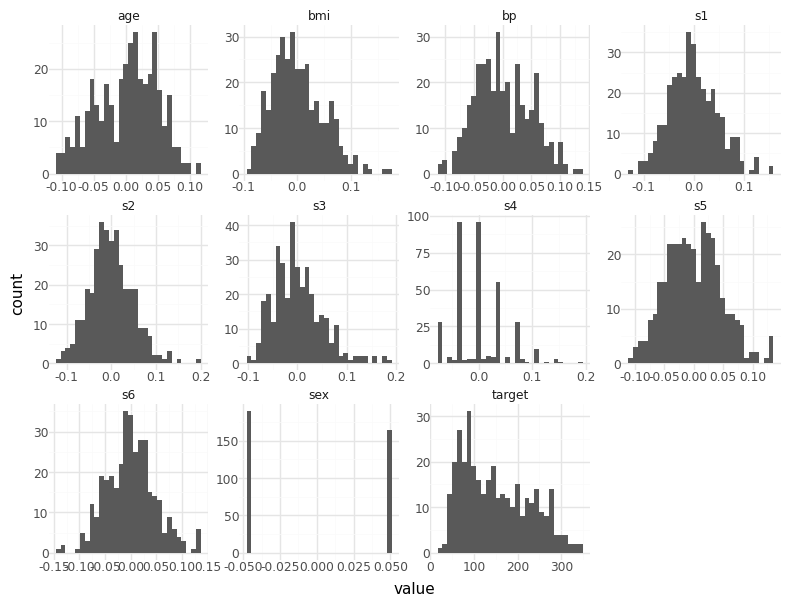

In [ ]:
# Example with theme_minimal()

In [ ]:
toplot_df = df.melt(...)
(
    ggplot(toplot_df, aes(x= ...)) +
    geom_histogram(...) +
    facet_wrap(... , scales ='free') +
    theme_minimal() +
    theme(figure_size=(8,6))
)

### 1.3.2 What do you notice? (0.125 points)
- เห็นอะไรบ้างจาก graph ด้านบน. subgraphs แต่ละอันคือ features ให้เขียนด้านล่างว่ามีอะไรบ้าง

**Answer**:

### 1.3.3 Pandas Scatter Plot Matrix (0.125 points)

- ในทางปฏิบัติ คุณควรตรวจสอบแผนภาพการกระจาย (scatter plots) ของคู่ตัวแปรทั้งหมดเพื่อตรวจสอบคู่ features ที่มีความสัมพันธ์กัน
- โดยทั่วไป คุณไม่ควรรวม features ที่มีความสัมพันธ์กันสูง คุณควรรวมเพียงหนึ่งในนั้น เพราะว่า โมเดลจะไม่รู้ว่าจะใช้ตัวไหนหรือแบ่งงานอย่างไร ถ้ามี features คล้ายกันมากๆ ปัญหานี้เรียกว่า **colinearity** ที่เคยพูดไปในคาบ
- วิธีหนึ่งในการตรวจสอบคือการใช้ `pandas.plotting.scatter_matrix` ([Documentation](https://pandas.pydata.org/docs/reference/api/pandas.plotting.scatter_matrix.html))
- รันโค้ดด้านล่าง คุณเห็น features ใดที่มี **highly correlated** (แสดงความสัมพันธ์เชิงเส้นใดๆ) หรือไม่? ใส่คำตอบในช่องด้านล่าง


In [ ]:
pd.plotting.scatter_matrix(df, alpha=0.2)

**Answer**:

## 1.4 Feature Selection and Engineering (0.25 points)

- หัวใจสำคัญของ ML คือการเลือก features เพื่อมาใช้เรียนรู้
- โดยทั่วไป คุณต้องมีความรู้ในโดเมนเพื่อทำการเลือก feature และ feature engineering ด้วยตนเองอย่างมีประสิทธิภาพ
- เนื่องจากเราไม่ใช่ผู้เชี่ยวชาญในเรื่องโรคเบาหวาน เราจะเลือกเพียงไม่กี่ feature ที่ไม่มีความสัมพันธ์กันสูงและทำการแปลงแบบ polynomial และ log บน feature ตัวเลขบางตัว

คำอธิบายงาน:
- สร้างชุดข้อมูลใหม่ 3 ชุดที่มีเฉพาะ feature ต่อไปนี้
  1. `X_train_small`: `age`, `sex`, `bmi`, `bp`, `s1`, `s4`, `s6`
  2. `X_train_small_poly`: `age`, `sex`, `bmi`, `bp`, `s1`, `s4`, `s6`, `s1^2`, `s4^2`, `s6^2`
    - `s1^2` หมายถึง `s1**2`
  3. `X_train_small_log`: `age`, `sex`, `bmi`, `bp`, `s1`, `s4`, `s6`, `log_s1`, `log_s4`, `log_s6`
    - เราจะใช้ลอการิทึมธรรมชาติ เฉพาะ `np.log1p()` ฟังก์ชันนี้เพิ่มค่าหนึ่งก่อนทำการคำนวณลอการิทึม (ทำไมเราจึงต้องเพิ่มหนึ่งก่อนคำนวณลอการิทึมในที่นี้?)
- **หมายเหตุ**: เพื่อให้โจทย์นี้ง่าย เราจะไม่ทำการ standardize feature ทั้งหมดในที่นี้ แต่ในทางปฏิบัติ (และในคำถามถัดไป) คุณควรทำ

In [ ]:
selected_features = ['age', 'sex', 'bmi', 'bp', 's1', 's4', 's6']

# 1. Select only the features listed above from X_train
X_train_small = X_train[selected_features].copy()

# 2. Start from X_train_small, then add polynomial features: s1^2, s4^2, s6^2
X_train_small_poly = X_train_small.copy()
X_train_small_poly['s1^2'] = ...
X_train_small_poly['s4^2'] = ...
X_train_small_poly['s6^2'] = ...

# 3. Start from X_train_small, then add log features: log_s1, log_s4, log_s6 (use np.log1p)
X_train_small_log = X_train_small.copy()
X_train_small_log['log_s1'] = ...
X_train_small_log['log_s4'] = ...
X_train_small_log['log_s6'] = ...

X_trains = {
  "small" : X_train_small,
  "small_poly" : X_train_small_poly,
  "small_log" : X_train_small_log
}

## 1.5 Cross-Validation for Model Selection (0.25 points)

- สำหรับขั้นตอนนี้ เราจะใช้ Cross-Validation เพื่อเลือกการรวมกันที่ดีที่สุดระหว่างโมเดลที่ดีที่สุดและfeature set
- เราจะพิจารณา 3 โมเดล:
  - linear regression (`LinearRegression()`)
  - lasso (`Lasso(alpha=1.0)`)
  - ridge regression (`Ridge(alpha=1.0)`)
- เราจะทำการทดสอบแบบ 5-fold cross-validation โดยใช้ `cross_val_score` กับการวัดความผิดพลาดแบบ negative mean squared error `scoring='neg_mean_squared_error'`
 - 'neg_mean_squared_error' คือแค่ -1 * mean squared error เท่านั้น `sklearn` มีเมตริกนี้เนื่องจากใช้หลักการว่าค่าที่สูงกว่าคือค่าที่ดีกว่า
 - [เอกสารอ้างอิง](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)
- **Note**: พยายามทำความเข้าใจ code อันนี้


In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0)
}

cv_results = []

for model_name, model in models.items():
  for X_name, X_temp in X_trains.items():
    cv_scores = cross_val_score(estimator = ...,
                                X = ...,
                                y = ...,
                                cv = ...,   #Fill in your answer here
                                scoring='neg_mean_squared_error')
    mean_cv_mse = -cv_scores.mean()  # We multiply by -1* because we want MSE and not negative MSE.
    cv_results.append({
         'Feature Set': X_name,
         'Model': model_name,
         'Mean CV MSE': mean_cv_mse,
    })

cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)

## 1.6 Fitting the best model to the full training data (0.25 points)

- สุดท้าย เราจะทำการ fit โมเดลที่ดีที่สุด + feature set บนข้อมูลฝึกฝนเต็มรูปแบบ (`X_train`)
- หลังจาก fitting แล้ว ให้พิมพ์ค่า coefficient `.coef_`

In [ ]:
best_model = ...
X_train_best = ...

# Fit the model again
best_model.fit(... , ...)

# print coef ของ model
print(best_model.coef_)

## 1.7 Explore the results (0.25 points)

- คำนวณค่า Mean Squared Error สำหรับข้อมูลฝึกสอน (train) และข้อมูลทดสอบ (test) และแสดงผลลัพธ์ออกมา
- คุณอาจพบว่าฟังก์ชัน `mean_squared_error()` มีประโยชน์ [เอกสารอ้างอิง](https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.mean_squared_error.html)
- สำหรับ testing data จะต้อง ทำการสร้าง data ที่มี features เสร็จเดียวกันกับ training data ก่อน!

In [ ]:
mse_train = ...

mse_test = ...


print(f"Training MSE {mse_train:.2f}. Testing MSE {mse_test:.2f}")

<br>

---

# 2. Housing Dataset (3 points)

สำหรับคำถามนี้ เราจะใช้ข้อมูลที่อยู่อาศัยจาก [Kaggle](https://www.kaggle.com/competitions/home-data-for-ml-course/data) competition

ข้อมูลชุดนี้มี features เยอะมากและต้องการการ clean data หลายขั้นตอน เราได้ทำขั้นตอนการ clean data ให้แล้ว เพื่อให้นักศึกษาโฟกัสกับขั้นตอนของ ML workflow

**ขั้นตอนที่ทำให้แล้ว (Data Cleaning)**:
1. ลบ features ที่มี missing values มาก (< 1000 non-null)
2. ลบ features ที่มีค่าส่วนใหญ่เป็นค่าเดียว (> 90%)
3. ลบ features ที่มี correlation สูง (> 0.8) ออก
4. ลบ extreme outliers
5. ลบแถวที่มี missing data (dropna)
6. แปลง categorical features ด้วย one-hot encoding

## 2.0 Load and Clean the data

In [ ]:
!wget -O house_train.csv https://github.com/yongsa-nut/TU_CN240_DataScience_671/raw/refs/heads/main/Data/train.csv

In [ ]:
# Loading the data
house_df = pd.read_csv("house_train.csv", index_col=0)
print(f"Original shape: {house_df.shape}")
house_df.head()

## 2.1 Data Cleaning (provided)

ข้อมูลชุดนี้ต้องการการ clean data หลายขั้นตอน โค้ดด้านล่างทำให้แล้ว ให้ **run ทีละ cell** แล้วสังเกตว่าข้อมูลเปลี่ยนแปลงอย่างไรในแต่ละขั้นตอน

### Step 1: Drop features with too many missing values

- ถ้า feature มี missing values เยอะมาก (< 1000 จาก 1460 แถว) แสดงว่าข้อมูลไม่เพียงพอสำหรับการเรียนรู้
- มาดูก่อนว่า features ไหนมี missing values เยอะ

In [ ]:
# ดูจำนวน missing values ของแต่ละ feature
missing = house_df.isnull().sum()
print("Features with missing values:")
print(missing[missing > 0].sort_values(ascending=False))
print(f"\nTotal features: {len(house_df.columns)}")

In [ ]:
# ลบ features ที่มี non-null น้อยกว่า 1000
col_to_drop = [col for col in house_df.columns if house_df[col].notna().sum() < 1000]
print(f"Features to drop: {col_to_drop}")
house_df_clean = house_df.drop(labels=col_to_drop, axis=1)
print(f"Shape: {house_df.shape} -> {house_df_clean.shape}")

### Step 2: Remove features with mostly one value

- ถ้า feature มีค่าเดียวเป็นส่วนใหญ่ (> 90%) มันไม่ช่วยแยกแยะข้อมูล
- เราจะแยก features เป็น numerical กับ categorical แล้วตรวจสอบทั้งสองกลุ่ม

In [ ]:
# ดูสัดส่วนของค่าที่พบบ่อยที่สุดในแต่ละ feature
numeric_ = house_df_clean.select_dtypes(exclude=['object']).copy()
numeric_ = numeric_.drop(['MSSubClass'], axis=1)
cat_ = house_df_clean.select_dtypes(include=['object']).copy()
cat_['MSSubClass'] = house_df_clean['MSSubClass']

print("Categorical features - top value proportion:")
for col in cat_.columns:
    top_pct = cat_[col].value_counts().iloc[0] / len(cat_)
    if top_pct > 0.8:
        print(f"  {col}: {top_pct:.1%} (top value: '{cat_[col].value_counts().index[0]}')")

print("\nNumerical features - top value proportion:")
for col in numeric_.columns:
    top_pct = numeric_[col].value_counts().iloc[0] / len(numeric_)
    if top_pct > 0.8:
        print(f"  {col}: {top_pct:.1%} (top value: {numeric_[col].value_counts().index[0]})")

In [ ]:
# ลบ features ที่มีค่าเดียว > 90%
threshold = 0.9
mostly_one = []
for col in cat_.columns:
    highest_count = cat_[col].value_counts().iloc[0]
    if highest_count / len(cat_) > threshold:
        mostly_one.append(col)
for col in numeric_.columns:
    highest_count = numeric_[col].value_counts().iloc[0]
    if highest_count / len(numeric_) > threshold:
        mostly_one.append(col)

print(f"Low-variance features to drop ({len(mostly_one)}): {mostly_one}")
house_df_clean = house_df_clean.drop(mostly_one, axis=1)
print(f"Shape: {house_df_clean.shape}")

### Step 3: Remove highly correlated features

- ถ้า 2 features มี correlation > 0.8 พวกมันให้ข้อมูลซ้ำกัน → เกิดปัญหา **multicollinearity**
- เราจะเก็บไว้แค่ตัวเดียวของแต่ละคู่

In [ ]:
# ดูคู่ features ที่ correlated สูง
numeric_ = house_df_clean.select_dtypes(exclude=['object']).copy()
numeric_ = numeric_.drop(['MSSubClass'], axis=1, errors='ignore')
corr_matrix = numeric_.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

print("Highly correlated pairs (> 0.8):")
for col in upper.columns:
    for idx in upper.index:
        if upper.loc[idx, col] > 0.8:
            print(f"  {idx} <-> {col}: {upper.loc[idx, col]:.3f}")

In [ ]:
# ลบ feature ที่มาทีหลังในแต่ละคู่
to_remove = [col for col in upper.columns if any(upper[col] > 0.8)]
print(f"Features to drop: {to_remove}")
house_df_clean = house_df_clean.drop(to_remove, axis=1)
print(f"Shape: {house_df_clean.shape}")

### Step 4: Remove extreme outliers

- Outliers ที่มีค่าสูงผิดปกติอาจทำให้โมเดลเรียนรู้ผิดพลาด
- มาดูค่า max ของ features ที่น่าสงสัยก่อน

In [ ]:
# ดูค่า extreme ของ features ที่น่าสงสัย
for col in ['LotFrontage', 'LotArea', 'BsmtFinSF1', 'GrLivArea']:
    if col in house_df_clean.columns:
        s = house_df_clean[col].describe()
        print(f"{col}: mean={s['mean']:.0f}, max={s['max']:.0f}, 99%={house_df_clean[col].quantile(0.99):.0f}")

In [ ]:
# ลบแถวที่มีค่า extreme
house_df_clean = house_df_clean[~(
    (house_df_clean.get('LotFrontage', pd.Series(dtype=float)) > 200) |
    (house_df_clean.get('LotArea', pd.Series(dtype=float)) > 100000) |
    (house_df_clean.get('BsmtFinSF1', pd.Series(dtype=float)) > 4000) |
    (house_df_clean.get('GrLivArea', pd.Series(dtype=float)) > 4000)
)]
print(f"After removing outliers: {house_df_clean.shape}")

### Step 5: Drop remaining missing data

- เพื่อความง่าย เราจะลบแถวที่ยังมี missing data เหลืออยู่
- (วิธีที่ดีกว่าคือ impute ข้อมูลแทน แต่จะไม่ทำในการบ้านนี้)

In [ ]:
# ดูจำนวน missing values ที่เหลือ
remaining = house_df_clean.isnull().sum()
print(f"Features with remaining NaN: {(remaining > 0).sum()}")
print(f"Total NaN values: {remaining.sum()}")
print(f"Rows before: {len(house_df_clean)}")

In [ ]:
house_df_clean = house_df_clean.dropna()
print(f"After dropping NaN rows: {house_df_clean.shape}")

### Step 6: One-hot encoding

- Categorical features (เช่น "Neighborhood", "HouseStyle") ต้องแปลงเป็นตัวเลขก่อนใช้กับ linear regression
- เราใช้ **one-hot encoding** (`pd.get_dummies`) เพื่อสร้างคอลัมน์ 0/1 สำหรับแต่ละค่า

In [ ]:
# ดู categorical features ที่เหลือ
cat_cols = house_df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features to encode ({len(cat_cols)}): {cat_cols}")

In [ ]:
house_df_final = pd.get_dummies(house_df_clean)
print(f"After one-hot encoding: {house_df_final.shape}")

## 2.2 Explore the cleaned data

- ใช้ `.info()` และ `.describe()` เพื่อดูข้อมูลเบื้องต้นของ `house_df_clean`

In [ ]:
house_df_clean.info()

In [ ]:
house_df_clean.describe()

## 2.3 Visualize the numerical features using histogram (0.5 points)

- สร้าง histogram สำหรับ numerical features ทั้งหมดโดยใช้ `melt()` + `facet_wrap()`
- ใช้ `select_dtypes(exclude=['object'])` เพื่อเลือกเฉพาะตัวแปรเชิงตัวเลข

In [ ]:
numeric_df = house_df_clean.select_dtypes(exclude=['object']).copy()
toplot_df = numeric_df.melt(var_name=..., value_name=...)
(
    ggplot(toplot_df, aes(x=...)) +
    geom_histogram(bins=...) +
    facet_wrap('~feature', scales='free') +
    theme_minimal() +
    theme(figure_size=(10, 8))
)

## 2.4 Visualize the categorical features using barplot (0.5 points)

- สร้าง barplot สำหรับ categorical features ทั้งหมดโดยใช้ `melt()` + `facet_wrap()`
- ใช้ `select_dtypes(include=['object'])` เพื่อเลือกเฉพาะตัวแปร categorical

## 2.5 Create train and test dataset (0.5 points)

- สร้าง `X_train`, `X_test`, `y_train`, `y_test` จาก `house_df_final`
- Target variable คือ `SalePrice`
- Test size = 20%, `random_state = 777`

In [ ]:
X = house_df_final.drop(["SalePrice"], axis=1).copy()
y = house_df_final["SalePrice"]
X_train, X_test, y_train, y_test = ...

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

## 2.6 Scaling the data (0.25 points)

- ด้วย features ที่หลากหลาย เราจำเป็นต้อง scale ข้อมูลให้อยู่ในช่วงเดียวกัน
- เราจะใช้ `StandardScaler` ซึ่งจะแปลงให้ mean=0 และ std=1
- **สำคัญ**: ต้อง `.fit()` กับ `X_train` เท่านั้น ห้ามรวม `X_test` (เพราะอะไร? → data leakage!)
- จากนั้นใช้ `.transform()` เพื่อแปลง `X_train`

In [ ]:
scaler = StandardScaler()
scaler.fit(...)          # fit กับ training data เท่านั้น
X_train = scaler.transform(...)  # transform training data

## 2.7 Checking SalePrice distribution (provided)

- มาดู distribution ของ `SalePrice` (target variable) กัน

In [ ]:
(
    ggplot(pd.DataFrame({'SalePrice': y_train}), aes(x='SalePrice')) +
    geom_histogram(bins=30) +
    theme_minimal() +
    ggtitle("SalePrice distribution (before log transform)")
)

- จะเห็นว่า SalePrice มีค่าสูงมากและเบ้ไปทางขวา (right-skewed) ซึ่งอาจทำให้ MSE ถูก dominate โดยค่าที่สูงมากๆ
- เราจะทำ **log transform** เพื่อทำให้ distribution ใกล้เคียง normal มากขึ้น
- **หมายเหตุ**: หลังจากนี้เรากำลังทำนายค่า **log** ของ SalePrice (ต้องใช้ `np.exp()` ถ้าอยากได้ค่าจริง)

In [ ]:
y_train = np.log(y_train)
y_test = np.log(y_test)

In [ ]:
(
    ggplot(pd.DataFrame({'SalePrice': y_train}), aes(x='SalePrice')) +
    geom_histogram(bins=30) +
    theme_minimal() +
    ggtitle("SalePrice distribution (after log transform)")
)

## 2.8 Use Cross-validation to find the best model (0.75 points)

- ใช้ 5-fold Cross-Validation เพื่อเปรียบเทียบ 5 models ด้านล่าง
- ใช้ `cross_val_score` กับ `scoring='neg_mean_squared_error'`
- เติม models ที่ขาดหายไปให้ครบ แล้ว fill in `cross_val_score`
- อ่านผลลัพธ์อย่างละเอียดแล้วเลือก model ที่ดีที่สุด

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression_alpha=1': ...,
    'Ridge Regression_alpha=.5': ...,
    'Lasso Regression_alpha=1': ...,
    'Lasso Regression_alpha=.5': ...
}

cv_results = []

for model_name, model in models.items():
    cv_scores = cross_val_score(...,
                                ...,
                                ...,
                                cv=...,
                                scoring=...)
    avg_score = -cv_scores.mean()
    cv_results.append({'model': model_name, 'avg_mse': avg_score})
    print(f"{model_name}: Mean MSE = {avg_score:.4f}")

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

## 2.9 Fitting the best model with the whole data (0.25 points)

- Fit โมเดลที่ดีที่สุดกับ training data ทั้งหมด
- คำนวณ MSE ของ train และ test
- อย่าลืมแปลง `X_test` ด้วย `scaler` ก่อน!

In [ ]:
best_model = ...

# Fit
best_model.fit(..., ...)

# Transform X_test
X_test_scaled = scaler.transform(X_test)

# Calculate MSE
mse_train = mean_squared_error(y_train, best_model.predict(X_train))
mse_test = mean_squared_error(y_test, best_model.predict(X_test_scaled))

print(f"MSE train is {mse_train:.4f}. MSE test is {mse_test:.4f}")

## 2.10 R-squared

- R-squared อยู่ระหว่าง 0-1 โดย 1.0 คือ perfect predictions
- ใช้ `r2_score(y_true, y_predict)` เพื่อตรวจสอบ

In [ ]:
from sklearn.metrics import r2_score

r2_train = r2_score(y_train, best_model.predict(X_train))
r2_test = r2_score(y_test, best_model.predict(X_test_scaled))
print(f"R2 train: {r2_train:.4f}")
print(f"R2 test: {r2_test:.4f}")

print(f"\nMSE train: {mse_train:.4f}")
print(f"MSE test: {mse_test:.4f}")

## 2.11 Summarize and Reflect (0.25 points)

จากการทำ HW ข้อนี้ทั้งหมด ให้อธิบายสรุป ML workflow ที่เราทำ โดยตอบคำถามต่อไปนี้:
1. ทำไมเราต้องทำ data cleaning ก่อน (เช่น ลบ features ที่มี missing values เยอะ, ลบ features ที่มีค่าเดียว, ลบ features ที่ correlated กันสูง, ลบ outliers)? แต่ละขั้นตอนช่วยอะไร?
2. ทำไมเราต้อง scale ข้อมูล และทำไมต้อง fit scaler กับ training data เท่านั้น?
3. ทำไมเราทำ log transform กับ SalePrice?
4. โมเดลไหนที่คุณเลือก? เพราะอะไร? Cross-validation ช่วยในการเลือกโมเดลอย่างไร?

**Answer**:

<br>

---

# 3. Spam/Ham Classification with Logistic Regression (5 points)

## Introduction

เราจะใช้สิ่งที่ได้เรียนรู้ในชั้นเรียนเพื่อสร้าง binary classifier ที่สามารถแยกแยะอีเมลสแปม (spam เช่น จดหมายขยะ, เชิงพาณิชย์, หรือจำนวนมาก) จากอีเมลแฮม (ham อีเมลปกติที่ไม่ใช่สแปม)

การบ้านประกอบด้วย 6 ส่วน:
- Initial Analysis ของข้อมูล
- Feature Engineering
- EDA (Exploratory Data Analysis)
- Basic Classification
- Evaluating Classification
- Use your own words

In [ ]:
# Run this cell to suppress all FutureWarnings.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
import numpy as np
import pandas as pd
from plotnine import *

<br>

---

## Data

ในการจำแนกอีเมล **เป้าหมายของเราคือการจำแนกอีเมลว่าเป็นสแปมหรือไม่เป็นสแปม** (เรียกว่า "ham") โดยใช้ features ที่สร้างจากข้อความในอีเมล ชุดข้อมูลนี้มาจาก [SpamAssassin](https://spamassassin.apache.org/old/publiccorpus/) ประกอบด้วยข้อความอีเมลและ label (0 สำหรับ ham, 1 สำหรับสแปม) training data มีตัวอย่างทั้งหมด 8,348  

**หมายเหตุ:** ชุดข้อมูลนี้มาจากปี 2004 ดังนั้นเนื้อหาของอีเมลอาจแตกต่างจากอีเมลในปี 2025 มาก

เรียกใช้เซลล์ต่อไปนี้เพื่อโหลดข้อมูลลงใน `DataFrame`

`DataFrame` ชื่อ `train` มีข้อมูลที่มีป้ายกำกับที่คุณจะใช้ฝึกโมเดลของคุณ มีสี่คอลัมน์:

1. `id`: ตัวระบุสำหรับตัวอย่างการฝึก
2. `subject`: หัวข้อของอีเมล
3. `email`: ข้อความของอีเมล
4. `spam`: 1 ถ้าอีเมลเป็นสแปม, 0 ถ้าอีเมลเป็น ham (ไม่ใช่สแปม)

In [ ]:
# Download and unzip the data file
!wget https://github.com/yongsa-nut/TU_CN240_DataScience_671/raw/refs/heads/main/Data/spam_train.zip
!unzip spam_train

In [ ]:
# Loading training datasets
original_training_data = pd.read_csv('/content/spam_train.csv')

# Convert the emails to lowercase as the first step of text processing.
original_training_data['email'] = original_training_data['email'].str.lower()

original_training_data.head()

<br/>

อันดับแรก เรามาตรวจสอบกันว่าข้อมูลของเรามี **ค่าที่หายไป (missing values)** หรือไม่ เซลล์ด้านล่างจะแสดงจำนวนค่า `NaN` ในแต่ละคอลัมน์ หากมีค่า `NaN` เราจะแทนที่ด้วยค่าตัวเติมที่เหมาะสม (เช่น ค่า `NaN` ในคอลัมน์ `subject` หรือ `email` จะถูกแทนที่ด้วยสตริงว่าง) สุดท้าย เราจะแสดงจำนวนค่า `NaN` ในแต่ละคอลัมน์หลังการแก้ไขนี้เพื่อยืนยันว่าไม่มีค่า `NaN` เหลืออยู่

**หมายเหตุ:** แม้ว่าจะไม่มีค่า `NaN` ในคอลัมน์ `spam` แต่เราควรระมัดระวังเมื่อแทนที่ label ที่เป็น `NaN` การทำเช่นนั้นโดยไม่พิจารณาให้ดีอาจทำให้เกิดความเอนเอียงที่มีนัยสำคัญในโมเดลของเรา

In [ ]:
print('Before imputation:')
print(original_training_data.isnull().sum())
original_training_data = original_training_data.fillna('')
print('------------')
print('After imputation:')
print(original_training_data.isnull().sum())

<br/>

---

## Part 1: Initial Analysis

ในเซลล์ด้านล่าง เราได้พิมพ์ข้อความของฟิลด์ `email` สำหรับอีเมลแฮมอันแรกและอีเมลสแปมอันแรกในชุด training data

In [ ]:
first_ham = original_training_data.loc[original_training_data['spam'] == 0, 'email'].iloc[0]
first_spam = original_training_data.loc[original_training_data['spam'] == 1, 'email'].iloc[0]
print("Ham Email:")
print(first_ham)
print("-------------------------------------------------")
print("Spam Email:")
print(first_spam)

### Question 1 (0.2 point)

จากด้านบน จงอธิบายว่า email ที่เป็น spam กับ ที่เป็น ham นั้นมีความแตกต่างกันอย่างไร

**Answer**:

### Training-Validation Split

- training data คือข้อมูลทั้งหมดที่เรามีสำหรับทั้งการฝึกฝนโมเดลและการ **ตรวจสอบความถูกต้อง** (validating) ของโมเดลที่เราฝึกฝน
- ดังนั้น เราจำเป็นต้องแบ่ง training data ออกเป็นชุดข้อมูลการฝึกฝน (training) และชุดข้อมูลตรวจสอบความถูกต้อง (validation) แยกกัน
- คุณจะต้องใช้ **validation data** เพื่อประเมินประสิทธิภาพของตัวจำแนกของคุณเมื่อคุณฝึกฝนเสร็จสิ้นแล้ว
- Note: seed (`random_state`) ถูกตั้งค่าเป็น 42 ซึ่งจะสร้างลำดับสุ่มเทียมของตัวเลขสุ่มที่เหมือนกันสำหรับนักเรียนทุกคน


In [ ]:
# This creates a 90/10 train-validation split on our labeled data.
from sklearn.model_selection import train_test_split

train, val = train_test_split(original_training_data,
                              test_size = 0.1,
                              random_state = 42)

<br>

---

## Part 2: Feature Engineering

- **Task**: นำข้อความของอีเมลมาทำนายว่าอีเมลนั้นเป็น ham หรือ spam
- นี่เป็นปัญหา **binary classification** ดังนั้นเราสามารถใช้ logistic regression เพื่อสร้างเป็น classifier ได้

- ในการฝึกสอนโมเดล logistic regression เราต้องการเมทริกซ์ feature ที่เป็นตัวเลข $\mathbb{X}$ และเวกเตอร์ของ binary labels $Y$ ที่สอดคล้องกัน

- ปัญหาหลักของเราตอนนี้คือ **ข้อมูลของเราเป็นข้อความทั้งหมด (email) ไม่ใช่ตัวเลข**

- เพื่อแก้ไขปัญหานี้ เราสามารถสร้าง features ที่เป็นตัวเลขจากข้อความอีเมลและใช้ features เหล่านั้นสำหรับ logistic regression

- แต่ละแถวของ $\mathbb{X}$ คืออีเมลหนึ่งฉบับ แต่ละคอลัมน์ของ $\mathbb{X}$ ประกอบด้วย feature หนึ่งตัวสำหรับทุกอีเมล

- การบ้านนี้จะแนะนำคุณผ่านการสร้าง feature อย่างง่าย และคุณจะสามารถสร้าง features ที่น่าสนใจมากขึ้นเมื่อคุณพยายามเพิ่มความแม่นยำของโมเดลของคุณ

---


### Question 2 (0.5 point)

- feature ที่เราจะใช้คือ feature ที่มาบอกว่า คำนี้ปรากฎในอีเมลล์หรือไหม

- **Task**: สร้างฟังก์ชัน `words_in_texts` ที่รับรายการคำที่น่าสนใจ (`words`) และ `Series` ของอีเมล (`texts`)

  - ฟังก์ชัน `words_in_texts` ควรสร้าง **2-dimensional `NumPy` array** ที่มีหนึ่งแถวสำหรับแต่ละอีเมลใน `texts` และหนึ่งคอลัมน์สำหรับแต่ละคำใน `words`
  
  - หากคำที่ $j$ ใน `words` ปรากฏอย่างน้อยหนึ่งครั้งในอีเมลที่ $i$ ใน `texts` array ที่ส่งออกควรมีค่าเป็น 1 ที่ตำแหน่ง $(i, j)$ มิฉะนั้น หากคำที่ $j$ ไม่ปรากฏในอีเมลที่ $i$ เลย ค่าที่ $(i, j)$ ค่าควรเป็น 0

  - เราจะใช้ `words_in_texts` กับชุดข้อมูลขนาดใหญ่ ดังนั้นการใช้รูปแบบการทำ vectorization (เช่น การใช้อาเรย์ `NumPy`, ฟังก์ชัน `Series.str` เป็นต้น) เป็นวิธีที่แนะนำ

For example:
```
>>> words_in_texts(['hello', 'bye', 'world'],
                   pd.Series(['hello', 'hello worldhello']))

array([[1, 0, 0],
       [1, 0, 1]])
```

- สิ่งสำคัญคือ เรา **ไม่ได้** คำนวณ *จำนวนครั้งที่ปรากฏ* ของแต่ละคำ; เพียงแค่ตรวจสอบว่าคำนั้นปรากฏอย่างน้อย *หนึ่งครั้ง* หรือไม่
- **สำคัญ**: ใช้เวลาสักครู่เพื่อทำความเข้าใจตัวอย่างด้วยตัวคุณเองหากจำเป็น —— การเข้าใจว่าฟังก์ชันนี้ทำงานอย่างไรเป็นขั้นตอนแรกที่สำคัญในการนำไปใช้
- ถ้าไม่แน่ใจว่าเกิดอะไรขึ้น ให้ทักมาถามได้นะครับ

**หมายเหตุ**: ถ้าไม่คุ้นเคยกับ numpy array แนะนำให้ทำ 2d-list แล้ว เปลี่ยน list เป็น numpy array ได้โดยใช้ `np.array(lst)`

In [ ]:
def words_in_texts(words, texts):
    """
    Args:
        words (list): Words to find.
        texts (Series): Strings to search in.

    Returns:
        A 2D NumPy array of 0s and 1s with shape (n, d) where
        n is the number of texts, and d is the number of words.
    """
    result = []
    for word in words:
        # Use Series.str.contains to check if each text contains the word
        # This returns a Series of True/False, convert to int (1/0)
        col = texts.str.contains(...).astype(int)
        result.append(col)

    # Stack the columns together and transpose so rows=texts, cols=words
    indicator_array = np.column_stack(result)
    return indicator_array

In [ ]:
# Run this cell to see what your function outputs. Compare the results to the example provided above.
words_in_texts(['hello', 'bye', 'world'], pd.Series(['hello', 'hello worldhello']))

## Part 3: EDA

- สิ่งที่เราต้องทำคือ หา features มาแยกระหว่าง spam กับ ham emails

- ไอเดียหนึ่งคือ **การเปรียบเทียบ the distribution of a single feature in spam emails เมื่อเทียบกับ the distribution of the same features in ham emails**

- สมมติว่า feature ที่เราสนใจเป็น feature ที่เป็นตัวบอกว่า คำนี้มีอยู่หรือไม่มีอยู่ในอีเมลล์ (binary indicator)

  - เราสามารถใช้ feature นี้มา ดูได้ว่า คำนี้ปรากฎใน spam กับ ham ต่างกันเท่าไร (proportion หรือ ratio)

### Question 3 (1 point)

จงสร้าง bar chart ในลักษณะที่เหมือนตัวอย่างด้านล่างที่มาเปรียบเทียบ the proportion of spam and ham emails ของคำที่**คุณเลือกมาเอง**.


- **เลือก 6 คำที่ไม่ได้อยู่ในตัวอย่างด้านล่าง** กราฟข้างล่างเป็นเพียงแค่ตัวอย่างเท่านัน
- คำที่เลือกมานั้นควรจะมี ความต่างในการปรากฎใน email spam กับ ปกติ
- `words_in_texts` function สามารถช่วยในการค้นหาสำหรับข้อนี้ได้

---

**คำใบ้ที่ 1:** นี่เป็นคำถามที่ค่อนข้างท้าทาย วิธีการที่แนะนำคือให้ดูตัวอย่าง bar plot ก่อนและทำความเข้าใจว่ากำลังแสดงอะไร - แต่ละแท่งหมายถึงอะไร? ความสูงหมายถึงอะไร?

**คำใบ้ที่ 2:** คุณอาจต้องการเริ่มต้นด้วยการทำลองสร้างกราฟด้านล่างให้เหมือนก่อน

**คำใบ้ที่ 3:** คุณอาจต้องใช้ `numpy.sum(axis=0)` เพื่อรวมเฉพาะมิติแรก (แถว)

**คำใบ้ที่ 4:** คุณจะต้องตั้งค่า `geom_bar` ดังนี้ `geom_bar(stat='identity', position='dodge')`

สุดท้าย คุณจะต้องเชื่อมโยงฟังก์ชันของ `pandas` บางตัวเข้าด้วยกัน ลองเพิ่มฟังก์ชันทีละตัวและดูว่ามีผลต่อ `DataFrame` อย่างไร

ให้ลองพิมพ์ `DataFrame` ออกมาดู เพื่อการแก้ไขข้อผิดพลาดขณะที่คุณพยายามให้ได้รูปแบบที่ต้องการตามด้านล่าง

In [ ]:
# Example of ansnwer. YOU MUST NOT USE THESE WORDS!!

,word,type,percentage
0,body,Ham,0.123682
1,business,Ham,0.087042
2,html,Ham,0.222163
3,money,Ham,0.058266
4,offer,Ham,0.062198
5,please,Ham,0.099553
6,body,Spam,0.519812
7,business,Spam,0.257039
8,html,Spam,0.595412
9,money,Spam,0.232534


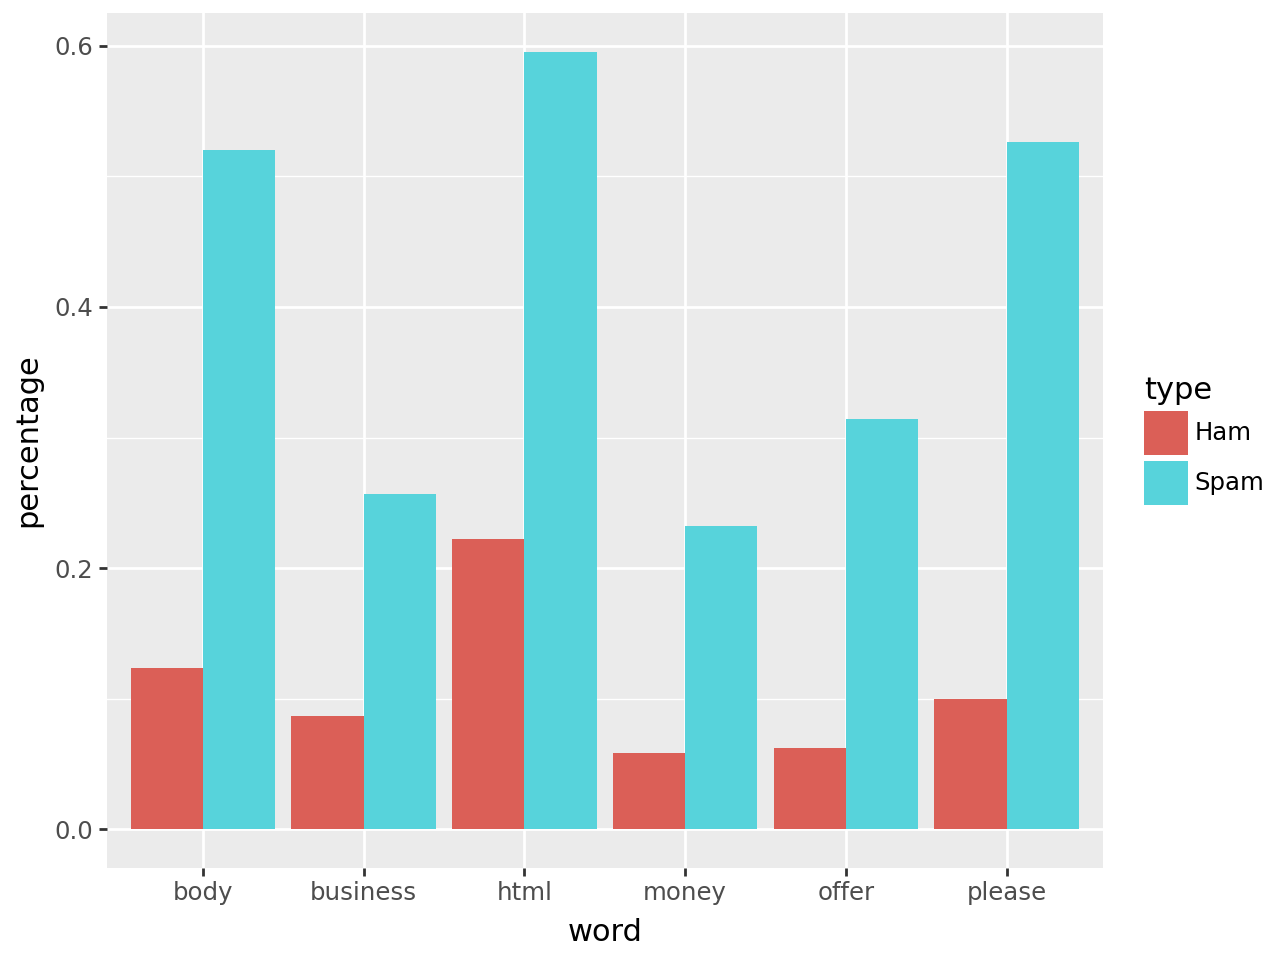

In [ ]:
# Example of ansnwer. YOU MUST NOT USE THESE WORDS!!

เมื่อ feature เป็นแบบ binary จึงมีความเหมาะสมที่จะเปรียบเทียบสัดส่วนของมันระหว่างคลาสต่างๆ (เหมือนในคำถามก่อนหน้า) มิฉะนั้น หาก feature สามารถมีค่าเป็นตัวเลขได้ เราสามารถเปรียบเทียบการกระจายตัวของค่าเหล่านี้สำหรับคลาสที่แตกต่างกัน

สร้าง bar chart ของคุณด้านล่างนี้:

In [ ]:
train = train.reset_index(drop=True)

# Choose your 6 words
your_six_words = [...]

# Separate spam and ham emails
spam_emails = train[train['spam'] == 1]
ham_emails = train[train['spam'] == 0]

# Calculate proportion of each word appearing in spam vs ham
spam_counts = words_in_texts(your_six_words, spam_emails['email']).sum(axis=0) / len(spam_emails)
ham_counts = words_in_texts(your_six_words, ham_emails['email']).sum(axis=0) / len(ham_emails)

# Build a DataFrame for plotting
df_your_words = pd.DataFrame({
    'word': your_six_words * 2,
    'type': ['Ham'] * len(your_six_words) + ['Spam'] * len(your_six_words),
    'percentage': list(ham_counts) + list(spam_counts)
})
df_your_words

In [ ]:
# Plot the bar chart using ggplot
(
    ggplot(df_your_words, aes(x='word', y='percentage', fill='type')) +
    geom_bar(stat='identity', position='dodge') +
    theme_minimal()
)

<br>

---

## Part 4: Basic Classification

สังเกตว่าผลลัพธ์ของ `words_in_texts(words, train['email'])` เป็นเมทริกซ์ตัวเลขที่มี features สำหรับแต่ละอีเมล ซึ่งหมายความว่าเราสามารถใช้มันโดยตรงเพื่อ train classifier ได้!

### Question 4 (0.5 points)

เราได้ให้คำ 5 คำที่อาจเป็นประโยชน์เป็น features ในการแยกความแตกต่างระหว่างอีเมลสแปม/แฮม

**ใช้คำเหล่านี้** (`some_words`) และ `DataFrame` ชื่อ `train` เพื่อสร้าง arrays ของ `NumPy` สองชุด: `X_train` และ `Y_train`
- `X_train` ควรเป็น array 2 มิติของเลข 0 และ 1 ที่สร้างโดยใช้ฟังก์ชัน `words_in_texts` ของคุณกับอีเมลทั้งหมดใน training set
- `Y_train` ควรเป็นเวกเตอร์ของ labels ที่ถูกต้องสำหรับแต่ละอีเมลใน training set

In [ ]:
some_words = ['drug', 'bank', 'prescription', 'memo', 'private']

X_train = ...
Y_train = ...

X_train[:5], Y_train[:5]

(array([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0]]),
 0    0
 1    0
 2    0
 3    0
 4    0
 Name: spam, dtype: int64)

### Question 5 (0.5 points)

ตอนนี้เรามี matrices แล้ว เราสามารถสร้างโมเดลด้วย `sklearn` ได้! โดยใช้ classifier [`LogisticRegression`](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) ฝึกโมเดล logistic regression โดยใช้ `X_train` และ `Y_train` จากนั้นให้แสดงผล training accuracy ของโมเดลด้านล่าง คุณควรจะได้ค่า accuracy ประมาณ $0.76$

In [ ]:
from sklearn.linear_model import LogisticRegression

my_model = ...
...

training_accuracy = ...
print("Training Accuracy: ", training_accuracy)

<br>

---

## Part 5: Evaluating Classifiers

ผลที่ออกมานั้นกำลังดี แต่ตัวจำแนกที่คุณสร้างขึ้นข้างต้นไม่ได้ดีเท่ากับที่ค่าความแม่นยำจะทำให้คุณเชื่อได้

ประการแรกเรากำลังประเมินความแม่นยำของโมเดลบน training data ซึ่งอาจเป็นการวัดที่ทำให้เข้าใจผิดได้ ความแม่นยำบน training data ไม่ได้แปลว่าจะมีความแม่นยำในโลกแห่งความเป็นจริง (บน testing data) เสมอไป

สมมติว่า ตัวจำแนกของเราจะถูกใช้สำหรับ **การกรอง** หรือป้องกันข้อความที่ถูกติดป้ายว่า `spam` ไม่ให้เข้าถึงกล่องขาเข้าของใครบางคน มีข้อผิดพลาดสองประเภทที่เราอาจทำได้:
- **False positive (FP)**: อีเมลที่เป็น ham ถูกระบุว่าเป็น spam และถูกกรองออกจากกล่องขาเข้า
- **False negative (FN)**: อีเมลที่เป็น spam ถูกติดป้ายผิดว่าเป็น ham และเข้าไปอยู่ในกล่องขาเข้า

เพื่อความชัดเจน เราติดป้ายอีเมล spam เป็น 1 และอีเมล ham เป็น 0 คำนิยามเหล่านี้ขึ้นอยู่กับทั้งป้ายที่ถูกต้องและป้ายที่ทำนาย false positives และ false negatives อาจมีความสำคัญที่แตกต่างกัน ซึ่งนำเราไปสู่การพิจารณาวิธีการประเมินตัวจำแนกเพิ่มเติมนอกเหนือจาก accuracy โดยรวม:

**Precision**: วัดสัดส่วนของอีเมลที่ถูกระบุว่าเป็น spam ที่เป็น spam จริง ๆ ในทางคณิตศาสตร์ คือ $\frac{\text{TP}}{\text{TP} + \text{FP}}$

**Recall**: วัดสัดส่วนของอีเมล spam ที่ถูกระบุว่าเป็น spam อย่างถูกต้อง ในทางคณิตศาสตร์ คือ $\frac{\text{TP}}{\text{TP} + \text{FN}}$

**False positive rate**: วัดสัดส่วนของอีเมล ham ที่ถูกระบุว่าเป็น spam อย่างไม่ถูกต้อง ในทางคณิตศาสตร์ คือ $\frac{\text{FP}}{\text{FP} + \text{TN}}$

วิธีจำสูตรแบบง่ายๆ คือ **P**recision เกี่ยวข้องกับ T**P** และ F**P**, ส่วน Recall ไม่เกี่ยวข้อง

Note: True Positive (TP) คืออีเมล spam ที่ถูกจำแนกว่าเป็น spam และ True Negative (TN) คืออีเมล ham ที่ถูกจำแนกว่าเป็น ham

### Question 6a (0.4 points)

สมมติว่าเรามี classifier ตัวหนึ่งที่เรียกว่า "zero predictor" สำหรับอีเมลที่ป้อนเข้าไปใดๆ **zero predictor จะทำนายเป็น 0 เสมอ (มันไม่เคยทำนายเป็น 1 สำหรับอีเมลใดๆ เลย)** (0 คือ ham และ 1 คือ spam)

Classifier นี้จะมี false positives และ false negatives กี่ตัวหากถูกประเมินบน training set ของเรา และผลลัพธ์ถูกเปรียบเทียบกับ `Y_train`?

จงเติมค่าของ `zero_predictor_fp` ซึ่งเท่ากับจำนวน false positives และ `zero_predictor_fn` ซึ่งเท่ากับจำนวน false negatives สำหรับ zero predictor สมมตินี้บน training data

In [ ]:
# Zero predictor always predicts 0 (ham) for every email.
# FP = ham emails predicted as spam = ? (think: does zero predictor ever predict spam?)
# FN = spam emails predicted as ham = ? (think: does zero predictor ever predict ham?)

zero_predictor_fp = ...
zero_predictor_fn = ...
zero_predictor_fp, zero_predictor_fn

### Question 6b (0.4 points)

What is the accuracy and recall of the zero predictor on the training data? Do not use any `sklearn` functions to compute these performance metrics.

Accuracy และ recall ของ zero predictor บน training data คืออะไร? ห้ามใช้ฟังก์ชันใดๆ จาก `sklearn` เพื่อคำนวณค่าด้านล่างต่อไปนี้

In [ ]:
# TP = spam emails correctly predicted as spam
zero_predictor_tp = ...

# Accuracy = (TP + TN) / total = correct predictions / total
zero_predictor_acc = ...

# Recall = TP / (TP + FN)
zero_predictor_recall = ...

zero_predictor_tp, zero_predictor_acc, zero_predictor_recall

### Question 6c (0.4 points)

คำนวณค่า precision, recall และ false positive rate ของ classifier `LogisticRegression` `my_model` จากคำถามข้อ 5 **ห้าม**ใช้ฟังก์ชันใดๆ จาก `sklearn` เพื่อคำนวณเมตริกการวัดประสิทธิภาพ; เมธอดเดียวจาก `sklearn` ที่คุณสามารถใช้ได้ในที่นี้คือ `.predict` เพื่อสร้างการทำนายโมเดลโดยใช้ `my_model` และ `X_train`

In [ ]:
Y_train_hat = my_model.predict(X_train)

# Compare predictions (Y_train_hat) with actual labels (Y_train)
TP = ((Y_train_hat == 1) & (Y_train == 1)).sum()
TN = ...
FP = ...
FN = ...

logistic_predictor_precision = ...  # TP / (TP + FP)
logistic_predictor_recall = ...     # TP / (TP + FN)

print(f"{TP=}, {TN=}, {FP=}, {FN=}")
print(f"{logistic_predictor_precision=:.2f}, {logistic_predictor_recall=:.2f}")

### Question 6d (0.2 points)

 ความแม่นยำของ logistic regression classifier `my_model` เปรียบเทียบกับความแม่นยำของ zero predictor อย่างไร?

Answer:

### Question 6e (0.2 points)

จากคำ features ที่ให้ในข้อ 4 จงอภิปรายว่าเพราะเหตุใด logistic regression classifier `my_model` อาจทำงานได้ไม่ดี

**คำใบ้:** ลองคิดดูว่าคำเหล่านี้พบบ่อยแค่ไหนในชุดอีเมล

Answer:

### Question 6f (0.2 points)

`my_model` หรือ zero predictor ดีกว่ากัน เพราะอะไร จงอธิบายโดยใช้ evaluation metrics หนึ่งตัว ด้านบนที่คำนวณมาด้านบนมารวมด้วย

**Answer**:

<br>

---

## Part 6: Use your words

### Q7 (0.5 points)

- ทำซ้ำในส่วนที่ 4 โดยใช้คำ 6 คำที่คุณเลือก
- รายงานทั้ง training accuracy และ validation accuracy

In [ ]:
...

training_accuracy = ...
print("Training Accuracy: ", training_accuracy)
validation_accuracy = ...
print("Validation Accuracy: ", validation_accuracy)